# WandB Learning Curve Extractor

This notebook pulls experiment curves from WandB, filters runs by config, aggregates multiple seeds, and plots mean +- std.

## How to use
1. Update the configuration cell (entity, project, metrics, and experiment filters).
2. Run all cells.
3. Inspect matched run/seed summary and the generated plot.

In [19]:
import math
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import wandb

# Optional: if you are not logged in yet, uncomment the next line.
# wandb.login()

print("Imports loaded.")

Imports loaded.


In [30]:
# -----------------------------
# User configuration (edit me)
# -----------------------------
DEFAULT_ENTITY = "glen-berseth"
DEFAULT_PROJECT = "purejaxrl_continuous_control_with_goals_from_mlp_teacher_emp_subsample_emp_second_sweep"

# Default learning-curve metrics used in this repo:
# x_metric="_step" and y_metric="episodic_return"
X_METRIC = "_step"
Y_METRIC = "eval/success_rate"

# Allowed run states include: "finished", "running", "crashed", "failed"
ALLOWED_STATES = ["finished", "running", "crashed"]

# Speed/quality tradeoff when reading history:
# - "sampled": much faster, downsample each run history to SAMPLES_PER_RUN points
# - "scan": full history (slowest)
HISTORY_MODE = "sampled"
SAMPLES_PER_RUN = 2000
MAX_RUNS_PER_EXPERIMENT = None  # e.g. 30 to cap runtime on huge projects

# Aggregation options:
# - "union_interp": union of x grid, interpolate each run on that grid (recommended)
# - "union_exact": union of x grid, no interpolation (missing values become NaN)
# - "intersection_exact": only x values present in every run
ALIGNMENT_MODE = "union_interp"

SMOOTHING_WINDOW = 1  # set >1 for moving-average smoothing

PLOT_TITLE = "Ant-u-maze-single-goal"
X_LABEL = "Step"
Y_LABEL = "Success Rate"
FIGSIZE = (9, 5)
FONT_SIZE = 12  # title, axis labels, legend, and tick labels
LEGEND_LOC = "best"
SHADE_ALPHA = 0.2
LINEWIDTH = 2.0
SAVE_PATH = None  # Example: "artifacts/wandb_learning_curve.png"

# Define each experiment with filters and legend text.
# - "name": internal identifier
# - "legend": label shown on plot (optional, defaults to name)
# - Optional "entity" and "project": override defaults for this experiment
# - "config_filters": exact-match dict against run.config
# - Optional key "extra_predicate": callable (run) -> bool
EXPERIMENTS = [
    {
        "name": "exp_a",
        "legend": "Student with Teacher",
        # "entity": "glen-berseth",
        # "project": "some_other_project",
        "config_filters": {
            # "USE_LEARNING_PROGRESS_REWARD": False,
            "ENT_COEF": 0.0,
            # "TEACHER_ENT_COEF": 0.0,
            "LR": 0.0003,
            "TEACHER_LR": 0.0003,
            "NUM_ENVS": 256,
            "NUM_STEPS": 64,
            # "ABSOLUTE_LEARNING_PROGRESS":False ,
            "GOAL_REWARD_COEF": 1.0,
            # "TASK_REWARD_WEIGHT": 1.0,
            # "NUM_EVAL_ENVS": 8,
            # "TEACHER_ROLLOUT_BUFFER_SIZE":30,
            "EMPOWERMENT_HIDDEN_DIM": 256,
            "TEACHER_ACTIVATION": "relu",
            "EMPOWERMENT_NUM_LAYERS": 3,
            "EMPOWERMENT_NUM_MINIBATCHES": 2,
            "EMPOWERMENT_UPDATE_EPOCHS": 2,
            "EMPOWERMENT_CONTRASTIVE_LOSS": "fwd_infonce",
            "TEACHER_ROLLOUT_BUFFER_SIZE": 1,
            "GOAL_REWARD_COEF": 1,

        },
    },
    # {
    #     "name": "exp_b",
    #     "legend": "With uniformly random Teacher",
    #     # "entity": "glen-berseth",
    #     "project": "purejaxrl_ant_u_maze_single_goal",
    #     "config_filters": {
    #         "NUM_MINIBATCHES": 8,
    #         "TEACHER_UNIFORM_RANDOM": True
    #     },
    # },
    {
        "name": "exp_c",
        "legend": "Without Teacher",
        "entity": "glen-berseth",
        "project": "purejaxrl",
        "config_filters": {
            "NUM_MINIBATCHES": 16,
            # "TEACHER_UNIFORM_RANDOM": "null"
            "TOTAL_TIMESTEPS": 300000000
        },
        "extra_predicate": lambda run: "TEACHER_UNIFORM_RANDOM" not in (run.config or {}),

    },
]

if not DEFAULT_ENTITY or not DEFAULT_PROJECT:
    print("Set DEFAULT_ENTITY and DEFAULT_PROJECT before running plotting cells.")
else:
    print(f"Default source: {DEFAULT_ENTITY}/{DEFAULT_PROJECT}.")
print(f"History mode: {HISTORY_MODE}, samples/run: {SAMPLES_PER_RUN}")

Default source: glen-berseth/purejaxrl_continuous_control_with_goals_from_mlp_teacher_emp_subsample_emp_second_sweep.
History mode: sampled, samples/run: 2000


In [31]:
def _is_float_like(value: Any) -> bool:
    return isinstance(value, (float, np.floating)) and not isinstance(value, bool)


def _configs_equal(lhs: Any, rhs: Any) -> bool:
    if _is_float_like(lhs) or _is_float_like(rhs):
        try:
            return bool(math.isclose(float(lhs), float(rhs), rel_tol=1e-6, abs_tol=1e-9))
        except (TypeError, ValueError):
            return False
    return lhs == rhs


def run_matches_experiment(run: Any, experiment: Dict[str, Any], allowed_states: Sequence[str]) -> bool:
    if allowed_states and run.state not in allowed_states:
        return False

    config_filters = experiment.get("config_filters", {})
    run_config = dict(getattr(run, "config", {}) or {})
    for key, expected in config_filters.items():
        if key not in run_config:
            return False
        if not _configs_equal(run_config[key], expected):
            return False

    predicate = experiment.get("extra_predicate")
    if predicate is not None:
        return bool(predicate(run))

    return True


def _build_wandb_filters(
    config_filters: Optional[Dict[str, Any]],
    allowed_states: Sequence[str],
) -> Dict[str, Any]:
    filters: Dict[str, Any] = {}
    if allowed_states:
        filters["state"] = {"$in": list(allowed_states)}
    if config_filters:
        for key, value in config_filters.items():
            filters[f"config.{key}"] = value
    return filters


def fetch_runs(
    api: Any,
    entity: str,
    project: str,
    config_filters: Optional[Dict[str, Any]] = None,
    allowed_states: Sequence[str] = (),
) -> List[Any]:
    filters = _build_wandb_filters(config_filters, allowed_states)
    return list(api.runs(f"{entity}/{project}", filters=filters))

In [32]:
def extract_xy_from_run(
    run: Any,
    x_metric: str,
    y_metric: str,
    history_mode: str = "sampled",
    samples_per_run: int = 2000,
) -> Optional[Dict[str, Any]]:
    if history_mode == "scan":
        history_rows = run.scan_history(keys=[x_metric, y_metric])
    elif history_mode == "sampled":
        history_rows = run.history(
            keys=[x_metric, y_metric],
            samples=samples_per_run,
            pandas=False,
        )
    else:
        raise ValueError(f"Unknown HISTORY_MODE: {history_mode}")

    if hasattr(history_rows, "to_dict"):
        history_rows = history_rows.to_dict("records")

    rows: List[Tuple[float, float]] = []
    for row in history_rows:
        x_val = row.get(x_metric)
        y_val = row.get(y_metric)
        if x_val is None or y_val is None:
            continue
        if isinstance(x_val, (int, float, np.integer, np.floating)) and isinstance(
            y_val, (int, float, np.integer, np.floating)
        ):
            if np.isfinite(x_val) and np.isfinite(y_val):
                rows.append((float(x_val), float(y_val)))

    if not rows:
        return None

    x = np.array([r[0] for r in rows], dtype=np.float64)
    y = np.array([r[1] for r in rows], dtype=np.float64)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    # Collapse duplicate x values by averaging their y values.
    unique_x, inverse = np.unique(x, return_inverse=True)
    y_sum = np.zeros_like(unique_x, dtype=np.float64)
    y_count = np.zeros_like(unique_x, dtype=np.int64)
    for idx, inv in enumerate(inverse):
        y_sum[inv] += y[idx]
        y_count[inv] += 1
    unique_y = y_sum / np.maximum(y_count, 1)

    seed = dict(getattr(run, "config", {}) or {}).get("SEED")
    seed_key = seed if seed is not None else f"run:{run.id}"
    return {
        "run_id": run.id,
        "run_name": run.name,
        "seed": seed,
        "seed_key": seed_key,
        "x": unique_x,
        "y": unique_y,
    }


def moving_average(values: np.ndarray, window: int) -> np.ndarray:
    if window <= 1:
        return values
    kernel = np.ones(window, dtype=np.float64) / float(window)
    valid = np.isfinite(values).astype(np.float64)
    filled = np.where(np.isfinite(values), values, 0.0)
    num = np.convolve(filled, kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")
    out = np.full_like(values, np.nan, dtype=np.float64)
    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out


def _align_curves(
    x_arrays: Sequence[np.ndarray],
    y_arrays: Sequence[np.ndarray],
    alignment_mode: str,
) -> Tuple[np.ndarray, np.ndarray]:
    if alignment_mode == "intersection_exact":
        common = set(x_arrays[0].tolist())
        for x in x_arrays[1:]:
            common &= set(x.tolist())
        if not common:
            return np.array([], dtype=np.float64), np.empty((0, 0), dtype=np.float64)
        x_grid = np.array(sorted(common), dtype=np.float64)
        matrix = []
        for x, y in zip(x_arrays, y_arrays):
            mapping = {float(k): float(v) for k, v in zip(x, y)}
            matrix.append(np.array([mapping[val] for val in x_grid], dtype=np.float64))
        return x_grid, np.vstack(matrix)

    x_grid = np.unique(np.concatenate(x_arrays).astype(np.float64))
    y_matrix = np.full((len(x_arrays), len(x_grid)), np.nan, dtype=np.float64)
    for i, (x, y) in enumerate(zip(x_arrays, y_arrays)):
        if alignment_mode == "union_interp":
            y_matrix[i] = np.interp(x_grid, x, y, left=np.nan, right=np.nan)
        elif alignment_mode == "union_exact":
            positions = np.searchsorted(x_grid, x)
            y_matrix[i, positions] = y
        else:
            raise ValueError(f"Unknown alignment mode: {alignment_mode}")
    return x_grid, y_matrix


def _aggregate_xy_curves(
    curves: Sequence[Tuple[np.ndarray, np.ndarray]], alignment_mode: str
) -> Optional[Dict[str, np.ndarray]]:
    if not curves:
        return None
    x_arrays = [c[0] for c in curves]
    y_arrays = [c[1] for c in curves]
    x_grid, y_matrix = _align_curves(x_arrays, y_arrays, alignment_mode)
    if y_matrix.size == 0:
        return None

    mean = np.nanmean(y_matrix, axis=0)
    std = np.nanstd(y_matrix, axis=0)
    count = np.sum(~np.isnan(y_matrix), axis=0)
    valid = count > 0
    if not np.any(valid):
        return None

    return {
        "x": x_grid[valid],
        "mean": mean[valid],
        "std": std[valid],
        "count": count[valid],
    }


def aggregate_records_by_seed(
    records: Sequence[Dict[str, Any]], alignment_mode: str
) -> Optional[Dict[str, Any]]:
    if not records:
        return None

    per_seed: Dict[str, List[Tuple[np.ndarray, np.ndarray]]] = {}
    for record in records:
        key = str(record["seed_key"])
        per_seed.setdefault(key, []).append((record["x"], record["y"]))

    # If multiple runs share a seed, average those runs first.
    seed_curves: List[Tuple[np.ndarray, np.ndarray]] = []
    for seed_runs in per_seed.values():
        seed_agg = _aggregate_xy_curves(seed_runs, alignment_mode)
        if seed_agg is None:
            continue
        seed_curves.append((seed_agg["x"], seed_agg["mean"]))

    overall = _aggregate_xy_curves(seed_curves, alignment_mode)
    if overall is None:
        return None

    overall["num_seeds"] = np.array([len(seed_curves)], dtype=np.int64)
    return overall

Queried experiment sources:
[exp_a | legend=Student with Teacher] source=glen-berseth/purejaxrl_continuous_control_with_goals_from_mlp_teacher_emp_subsample_emp_second_sweep fetched_runs=1 matched_runs=1 curve_runs=1 unique_seeds=[30]
[exp_c | legend=Without Teacher] source=glen-berseth/purejaxrl fetched_runs=1 matched_runs=1 curve_runs=1 unique_seeds=[30]
Saved figure to: ../plots/Ant-u-maze-single-goal_eval/success_rate.png


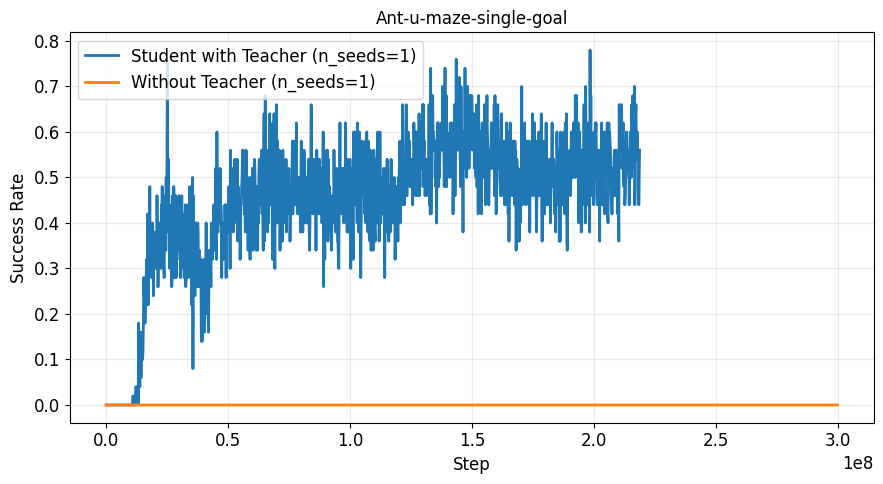

In [33]:
needs_default_source = any(
    (not exp.get("entity")) or (not exp.get("project")) for exp in EXPERIMENTS
)
if needs_default_source and (not DEFAULT_ENTITY or not DEFAULT_PROJECT):
    raise ValueError(
        "Set DEFAULT_ENTITY and DEFAULT_PROJECT, or provide entity/project on every experiment."
    )

api = wandb.Api(timeout=60)

# Caches speed up repeated runs of this cell.
runs_cache: Dict[Tuple[str, str, Tuple[Tuple[str, Any], ...], Tuple[str, ...]], List[Any]] = {}
history_cache: Dict[Tuple[str, str, str, str, int], Optional[Dict[str, Any]]] = {}


def get_runs_for_experiment(entity: str, project: str, exp: Dict[str, Any]) -> List[Any]:
    config_filters = exp.get("config_filters", {})
    allowed_states_key = tuple(sorted(ALLOWED_STATES))
    filter_items = tuple(sorted(config_filters.items()))
    cache_key = (entity, project, filter_items, allowed_states_key)
    if cache_key not in runs_cache:
        runs_cache[cache_key] = fetch_runs(
            api=api,
            entity=entity,
            project=project,
            config_filters=config_filters,
            allowed_states=ALLOWED_STATES,
        )
    return runs_cache[cache_key]


plot_payloads: List[Tuple[str, str, Dict[str, Any], List[Dict[str, Any]]]] = []
summary_by_experiment: Dict[str, Dict[str, Any]] = {}
for exp in EXPERIMENTS:
    exp_name = exp["name"]
    exp_legend = exp.get("legend", exp_name)
    exp_entity = exp.get("entity", DEFAULT_ENTITY)
    exp_project = exp.get("project", DEFAULT_PROJECT)

    if not exp_entity or not exp_project:
        raise ValueError(
            f"Experiment '{exp_name}' must resolve to a non-empty entity and project."
        )

    candidate_runs = get_runs_for_experiment(exp_entity, exp_project, exp)
    if MAX_RUNS_PER_EXPERIMENT is not None:
        candidate_runs = candidate_runs[: MAX_RUNS_PER_EXPERIMENT]

    # Keep optional extra_predicate logic in Python.
    matched_runs = [
        run for run in candidate_runs if run_matches_experiment(run, exp, ALLOWED_STATES)
    ]

    records = []
    for run in matched_runs:
        hist_key = (run.id, X_METRIC, Y_METRIC, HISTORY_MODE, int(SAMPLES_PER_RUN))
        if hist_key not in history_cache:
            history_cache[hist_key] = extract_xy_from_run(
                run,
                X_METRIC,
                Y_METRIC,
                history_mode=HISTORY_MODE,
                samples_per_run=SAMPLES_PER_RUN,
            )
        item = history_cache[hist_key]
        if item is not None:
            records.append(item)

    summary_by_experiment[exp_name] = {
        "legend": exp_legend,
        "entity": exp_entity,
        "project": exp_project,
        "fetched_runs": len(candidate_runs),
        "matched_runs": len(matched_runs),
        "records": records,
    }

    agg = aggregate_records_by_seed(records, ALIGNMENT_MODE)
    if agg is not None and SMOOTHING_WINDOW > 1:
        agg["mean"] = moving_average(agg["mean"], SMOOTHING_WINDOW)
        agg["std"] = moving_average(agg["std"], SMOOTHING_WINDOW)

    if agg is not None:
        plot_payloads.append((exp_name, exp_legend, agg, records))

print("Queried experiment sources:")
for exp in EXPERIMENTS:
    exp_name = exp["name"]
    stats = summary_by_experiment[exp_name]
    records_for_exp = stats["records"]
    seen_seed_keys = sorted({str(r["seed_key"]) for r in records_for_exp})
    printable_seeds = sorted(
        {r["seed"] for r in records_for_exp if r.get("seed") is not None}
    )
    print(
        f"[{exp_name} | legend={stats['legend']}] "
        f"source={stats['entity']}/{stats['project']} "
        f"fetched_runs={stats['fetched_runs']} "
        f"matched_runs={stats['matched_runs']} "
        f"curve_runs={len(records_for_exp)} "
        f"unique_seeds={printable_seeds if printable_seeds else seen_seed_keys}"
    )
    if not records_for_exp:
        print(f"  Warning: no history found for metrics ({X_METRIC}, {Y_METRIC}).")

if not plot_payloads:
    raise ValueError("No plottable experiment data found. Check filters/metrics.")

plt.rcParams.update(
    {
        "font.size": FONT_SIZE,
        "axes.titlesize": FONT_SIZE,
        "axes.labelsize": FONT_SIZE,
        "legend.fontsize": FONT_SIZE,
        "xtick.labelsize": FONT_SIZE,
        "ytick.labelsize": FONT_SIZE,
    }
)
plt.figure(figsize=FIGSIZE)
for exp_name, exp_legend, agg, _ in plot_payloads:
    label = exp_legend
    x = agg["x"]
    mean = agg["mean"]
    std = agg["std"]
    n_seeds = int(agg["num_seeds"][0])
    if n_seeds > 0:
        label = f"{exp_legend} (n_seeds={n_seeds})"
    plt.plot(x, mean, label=label, linewidth=LINEWIDTH)
    plt.fill_between(x, mean - std, mean + std, alpha=SHADE_ALPHA)

plt.title(PLOT_TITLE)
plt.xlabel(X_LABEL)
plt.ylabel(Y_LABEL)
plt.legend(loc=LEGEND_LOC)
plt.grid(alpha=0.25)
plt.tight_layout()

SAVE_PATH=f"../plots/{PLOT_TITLE}_{Y_METRIC}.png"
SAVE_PATH_PDF=f"../plots/{PLOT_TITLE}_{Y_METRIC}.pdf"

if SAVE_PATH:
    import os
    os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
    plt.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")
    plt.savefig(SAVE_PATH_PDF, dpi=200, bbox_inches="tight")
    print(f"Saved figure to: {SAVE_PATH}")

plt.show()

In [34]:
!pwd

/home/mila/f/faisal.mohamed/git/empowerment_agent_assistance_ppo/examples
